# Set Up

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
experiments = [
    "famfold",
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]
palette = {
    "rnadist_100": "#7C87E9",
    "rnadist_200": "#2534BB",
    "rnadist_400": "#09157E",
    "samples_100": "#F189F5",
    "samples_200": "#A42E8A",
    "samples_400": "#8E0638",
    "hc_100": "#67DD67",
    "hc_200": "#0F690F",
    "hc_400": "#1a921a",
    "famfold": "#b3500e",
    "rna-llm": "gray",
}

In [24]:
sincfold_f1 = {
    "16s": 0.391664,
    "23s": 0.402430,
    "5s": 0.438967,
    "RNaseP": 0.442618,
    "grp1": 0.349969,
    "srp": 0.249175,
    "tRNA": 0.685143,
    "telomerase": 0.154173,
    "tmRNA": 0.350146,
}
# Crear DataFrame para sincfold
df_sincfold = pd.DataFrame(
    {
        "fam": list(sincfold_f1.keys()),
        "f1_post": list(sincfold_f1.values()),
        "modelo": "sincfold",
    }
)

# SincFold test and spy Best Epochs


In [25]:
PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/sincFold/SILVER/train_and_spy/best_epoch/sincFold_testnspy_best_epochs.csv"
df = pd.read_csv(PATH, index_col=0)
df.reset_index(inplace=True)
df.rename(columns={"index": "fam"}, inplace=True)
df.sort_values(by="fam", inplace=True)
df

,fam,famfold,rnadist_100,rnadist_200,rnadist_400,hc_100,hc_200,hc_400,samples_100,samples_200,samples_400
2,16s,0.367,0.354,0.367,0.382,0.358,0.364,0.374,0.372,0.368,0.383
0,23s,0.423,0.415,0.418,0.393,0.414,0.429,0.403,0.405,0.382,0.414
3,5s,0.531,0.501,0.533,0.497,0.486,0.542,0.498,0.500,0.526,0.509
6,RNaseP,0.391,0.443,0.467,0.424,0.470,0.478,0.427,0.480,0.445,0.456
4,grp1,0.397,0.379,0.395,0.418,0.384,0.394,0.422,0.396,0.385,0.400
5,srp,0.263,0.327,0.307,0.258,0.336,0.303,0.271,0.319,0.315,0.257
8,tRNA,0.639,0.653,0.695,0.691,0.669,0.672,0.680,0.655,0.684,0.713
1,telomerase,0.209,0.210,0.196,0.225,0.205,0.196,0.225,0.185,0.200,0.211
7,tmRNA,0.352,0.342,0.349,0.355,0.341,0.362,0.356,0.334,0.346,0.351


In [26]:
def normalizar_y_melt(df, rna_llm, experiments):
    rna_llm_series = pd.Series(rna_llm)
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(rna_llm_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1_post",
    )

    return dfn


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1_post",
)

dfn = normalizar_y_melt(df, sincfold_f1, experiments)

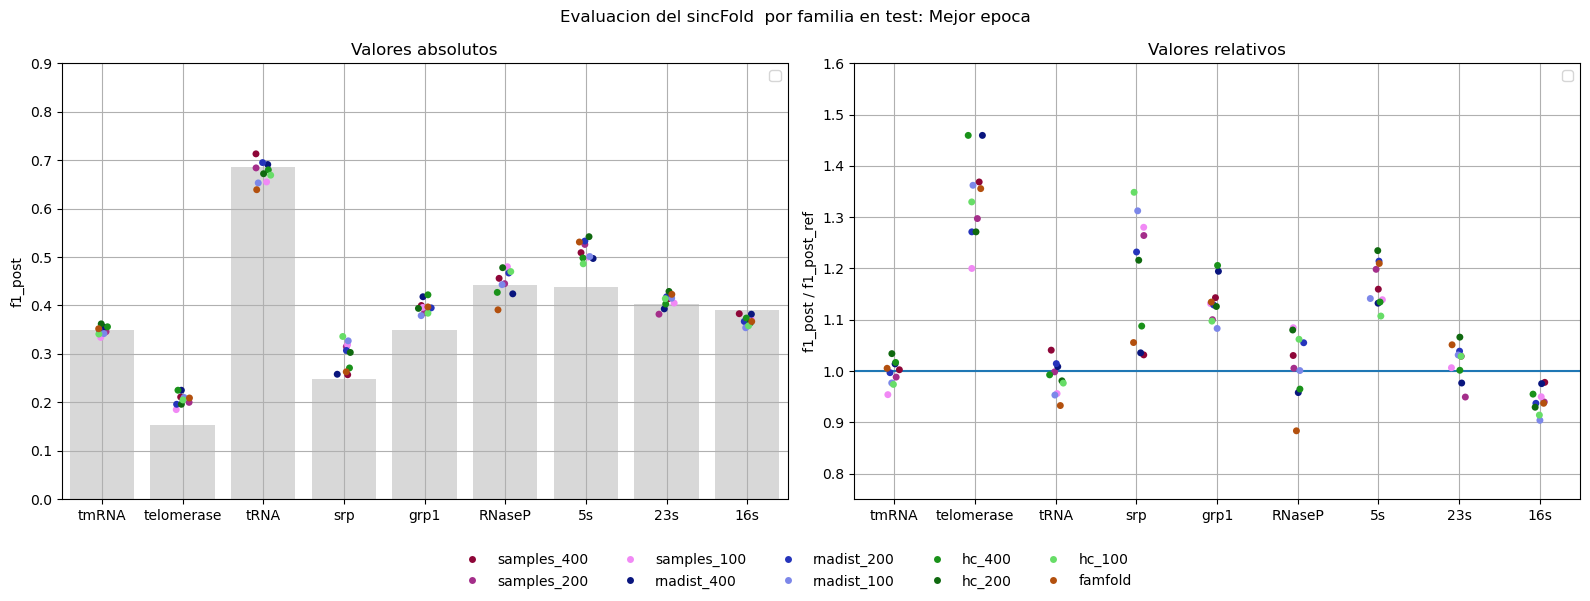

In [29]:
# Visualización categórica
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.stripplot(
    data=dfl.sort_values(by="modelo", ascending=False),
    x="fam",
    y="f1_post",
    hue="modelo",
    palette=palette,
    ax=axes[0],
)

sns.barplot(
    data=df_sincfold,
    x="fam",
    y="f1_post",
    color="gray",
    alpha=0.3,
    errorbar=None,
    ax=axes[0],
    legend=False,
)


sns.stripplot(
    data=dfn.sort_values(by="modelo", ascending=False),
    x="fam",
    y="f1_post",
    hue="modelo",
    palette=palette,
    ax=axes[1],
)
axes[0].set_ylim(0, 0.9)
axes[1].set_ylim(0.75, 1.6)
axes[0].grid()
axes[0].legend([])
axes[1].legend([])
axes[0].set_xlabel("")
plt.grid()
axes[0].set_title("Valores absolutos")
axes[1].set_title("Valores relativos")
fig.suptitle("Evaluacion del sincFold  por familia en test: Mejor epoca")
axes[1].set_ylabel("f1_post / f1_post_ref")
axes[0].tick_params(axis="x", rotation=0)
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_xlabel("")

axes[1].axhline(y=1)

# Leyenda global
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(), loc="lower center", ncol=5, frameon=False
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [28]:
s = dfn.groupby("modelo")["f1_post"].mean().sort_values().reset_index()
s = s.rename(columns={"f1_post": "rel_f1_post"})
s

,modelo,rel_f1_post
0,famfold,1.062735
1,samples_100,1.077919
2,samples_200,1.082274
3,rnadist_400,1.083739
4,rnadist_100,1.084940
5,samples_400,1.086940
6,hc_400,1.090837
7,hc_100,1.093055
8,rnadist_200,1.098685
9,hc_200,1.104205
